In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib as mpl

In [15]:
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6
mpl.rcParams['figure.autolayout'] = True
mpl.rcParams['font.size'] = 15
mpl.rcParams['errorbar.capsize'] = 3
mpl.rcParams['lines.markeredgewidth'] = 1
mpl.rcParams['axes.axisbelow'] = True

In [3]:
def batch_muon_directions(rng,N): # genera la dirección en la que se mueven N muones
    directions = np.empty((N,3)) # inicializa el array a llenar
    filled = 0
    while filled < N: # rejection sampling para el cos^2 con theta
        size = 2*(N-filled) # hace siempre el doble porque ese cómputo es menos costoso que repetir el loop
        theta = rng.uniform(0,np.pi/2,size)
        accept = rng.uniform(0,1,size) < np.cos(theta)**2 # chequea todos de una, más rápido
        theta = theta[accept]

#        phi = rng.uniform(0,2*np.pi,len(theta)) # samplea phi de una uniforme
        # estas dos líneas son si se quiere hacer 2D y que salga desde los dos sentidos y no de un solo lado
        signo = rng.integers(0,2,len(theta))
        phi = np.pi/2 + signo*np.pi
        sin_theta = np.sin(theta) # lo calculo una sola vez en lugar de 2
        new_dirs = np.stack([
            sin_theta*np.cos(phi),
            sin_theta*np.sin(phi),
            -np.cos(theta) # el vector apunta para el piso
        ],axis=1)
        
        to_add = min(N-filled,len(new_dirs)) # agrega las direcciones necesarias
        directions[filled:filled+to_add] = new_dirs[:to_add]
        filled += to_add
    
    return directions

def batch_generate_muon_t(det_size,det_delta,det_height,margin,rate,rng,N):
    x_length = det_size # la longitud del plano en la dirección en la que no roto es el lado de los centelladores
    y_length = det_delta+2*det_height+2*margin # en la dirección en la que roto es la longitud ocupada por los centelladores (distancia + alturas) sumando un margen a elección
    area = x_length*y_length
    
    ts = rng.exponential(scale=1/(rate*area),size=N) # sampleo el tiempo entre muones de una exponencial
    ts = np.cumsum(ts) # como samplear de la exponencial me da los interavlos entre muones, los sumo para tener los tiempos absolutos
    
    x_o = rng.uniform(-x_length/2,x_length/2,size=N) # sampleo de una uniforme 2D en el plano de generación
    y_o = rng.uniform(-y_length/2,y_length/2,size=N)
    z0 = det_height+det_delta/2
    z_o = np.full(N,z0) # la altura de generación es el punto medio entre los centelladores
    starts = np.stack([x_o,y_o,z_o],axis=1) # junto todo en un array de N vectores de 3 componentes

    flechas = batch_muon_directions(rng,N)
    return ts,starts,flechas

def generar_lluvia(det_size,det_delta,det_height,n,margin=0,seed=0,rate=1/60):
    rng = np.random.default_rng(seed) # defino el generador de números aleatorios

    muon_times,muon_starts,muon_flechas = batch_generate_muon_t(det_size,det_delta,det_height,margin,rate,rng,n)

    print(np.mean(np.diff(muon_times)))
    return muon_times,muon_starts,muon_flechas

def rotate_x(element,angle,center=[0,0,0]): # rota un elemento (nos va a interesar el centro de los cuadrados del detector) en un ángulo alrededor del eje paralelo a x que contiene el punto center 
    sen = np.sin(angle)
    cos = np.cos(angle)

    x,y,z = (element-center).T # descentro para hacer la rotación alrededor de ese punto
    rotated = np.stack([x,cos*y-sen*z,sen*y+cos*z],axis=-1)+center # sumo de vuelta el centro para volver a la posición absoluta
    return rotated # calcula la matriz de rotación y se la aplica al vector (que tiene que ser un array) sin tener que pasar por el producto matricial

normal_angle = lambda ang : np.array([0.0,-np.sin(ang),np.cos(ang)]) # genera el vector normal al cuadrado de los detectores dado que rotaron un cierto ángulo desde la posición vertical, los signos son por como es una rotación alrededor del eje x

def ray_plane_intersection(start,flecha,center,normal): # calcula el punto en el que la traza de un muón intersecta el plano que contiene a algún cuadrado de los detectores
    denom = np.dot(normal,flecha)
    
    if np.abs(denom) < 1e-6: # evita casos límites que son complicados numéricamente
        return None
    
    t = np.dot(normal,center-start)/denom # la distancia recorrida desde el punto start hasta el de intersección
    return start+t*flecha # devuelve el punto en el que ocurre la intersección

def calc_uv(normal): # calcula unos vectores de proyecciones que sirven para ver si un punto está adentro del cuadrado
    u = np.cross(normal,np.array([0,0,1]))
    if np.linalg.norm(u) < 1e-6:
        u = np.cross(normal,np.array([0,1,0]))
    u = u/np.linalg.norm(u) # coordenada 1 en el plano del detector
    v = np.cross(normal,u)
    v = v/np.linalg.norm(v) # coordenada 2 en el plano del detector
    return u,v

def is_point_in_square(point,center,normal,u,v,half_len): # una vez que tengo las coordenadas en el plano y el punto de intersección, proyecto este punto sobre estas coordenadas y me fijo si está dentro del cuadrado de interés en el plano.
    local_point = point - center # calculo la posición relativa al centro del plano
    u_dist = np.dot(local_point,u) # proyección en la coordenada 1 del pkano
    v_dist = np.dot(local_point,v) # proyección en la coordenada 2 del plano

    epsilon = 1e-10 # para mirar los casos límites
    return (-half_len - epsilon <= u_dist <= half_len + epsilon) and (-half_len - epsilon <= v_dist <= half_len + epsilon)

def intersect_square(start,flecha,center,normal,u,v,half_len):
    point = ray_plane_intersection(start,flecha,center,normal)
    if point is None:
        return False
    return is_point_in_square(point,center,normal,u,v,half_len)

def intersect_detector(start,flecha,center_top,center_bottom,normal,u,v,half_len):
    top_intersection = intersect_square(start,flecha,center_top,normal,u,v,half_len)
    if top_intersection:
        return True
    else:
        bottom_intersection = intersect_square(start,flecha,center_bottom,normal,u,v,half_len)
    return bottom_intersection

def sim_rotados(lluvia,det_size,det_height,det_xy,det_delta,freq,ang0=None,seed=0):
    if ang0 is None: # si no doy una posición inicial definida sampleo de una uniforme
        rng = np.random.default_rng(seed) # defino el generador de números aleatorios
        ang0 = rng.uniform(0,2*np.pi) # sampleo el ángulo inicial en el que se encuentra el par de centelladores respecto al eje z

    # ahora voy a definir las posiciones (verticales, sin rotar) de las caras de cada centellador. Todas comparten el centro en el plano xy. La de abajo de todo está en z = 0, y el resto sube según la altura de los centelladores y la distancia entre los mismos.
    center_top = np.array([*det_xy,det_delta + det_height])
    center_top_up = center_top + np.array([0,0,det_height])
    center_bottom = center_top - np.array([0,0,det_delta])
    center_bottom_down = center_bottom - np.array([0,0,det_height])

    rot_center = np.array([*det_xy,det_height + det_delta/2]) # defino el punto alrededor del cual rotan los centelladores, que se va a usar para descentrar, tiene que ser el punto medio entre los centros en posición vertical.
    
    measured_angles = []
    times,starts,flechas = lluvia

    ang = 0
        
    normal_new = normal_angle(ang) # calculo la nueva normal, la misma para todos los cuadrados
    u,v = calc_uv(normal_new) # calculo las proyecciones necesarias para las intersecciones
    center_top_new = rotate_x(center_top,ang,center=rot_center)
    center_top_up_new = rotate_x(center_top_up,ang,center=rot_center)
    center_bottom_new = rotate_x(center_bottom,ang,center=rot_center)
    center_bottom_down_new = rotate_x(center_bottom_down,ang,center=rot_center)

    muon_paths = []
    detected = np.zeros(len(times))
    for i in range(len(times)):
        start = starts[i]
        flecha = flechas[i]
        muon_paths.append((start,flecha))
        if intersect_detector(start,flecha,center_top_up_new,center_top_new,normal_new,u,v,det_size/2):
            if intersect_detector(start,flecha,center_bottom_new,center_bottom_down_new,normal_new,u,v,det_size/2):
                detected[i] = 1

    return muon_paths,detected

dist_centros = 24.7 # todas las distancias en cm
det_height = 1.1 # altura de los centelladores
det_size = 4.0 # ancho y largo de los centelladores
det_delta = dist_centros - det_height # 23.6 # distancia entre la cara superior del centellador inferior y la cara inferior del centellador superior
det_xy = [0,0] # punto en el plano xy que atraviesa el eje que contiene los centros de cada centellador en posición vertical
margin = 0
freq = 0 # vueltas por segundo

In [4]:
def draw_prism(ax,center,size,height=1.1,rot_ang=0,rot_center=[0,0,0], color='green', alpha=0.2):
    cx, cy, cz = center
    dx = dy = size / 2
    dz = height/2
    v = np.array([
        [cx - dx, cy - dy, cz - dz],
        [cx + dx, cy - dy, cz - dz],
        [cx + dx, cy + dy, cz - dz],
        [cx - dx, cy + dy, cz - dz],
        [cx - dx, cy - dy, cz + dz],
        [cx + dx, cy - dy, cz + dz],
        [cx + dx, cy + dy, cz + dz],
        [cx - dx, cy + dy, cz + dz],
    ])

    if rot_ang != 0:
        v_desc = v - rot_center
        v_desc = rotate_y(v_desc,rot_ang)
        v = v_desc + rot_center
    
    faces = [
        [v[j] for j in [0, 1, 2, 3]],
        [v[j] for j in [4, 5, 6, 7]],
        [v[j] for j in [0, 1, 5, 4]],
        [v[j] for j in [2, 3, 7, 6]],
        [v[j] for j in [1, 2, 6, 5]],
        [v[j] for j in [3, 0, 4, 7]],
    ]
    ax.add_collection3d(Poly3DCollection(faces, facecolors=color, edgecolors='black', alpha=alpha,zorder=10))
    return v

def connect_prisms(ax, v1, v2, color):
    for i in range(8):
        xs = [v1[i][0], v2[i][0]]
        ys = [v1[i][1], v2[i][1]]
        zs = [v1[i][2], v2[i][2]]
        ax.plot(xs, ys, zs, color=color, linestyle='dotted',alpha=0.4,zorder=0)

def rotate_y(element,angle): # función para rotar los cuadrados
    Ry = np.array([
        [np.cos(angle), 0, np.sin(angle)],
        [0, 1, 0],
        [-np.sin(angle), 0,  np.cos(angle)]
    ])
    return element @ Ry.T

def rotate_desc(element,center,ang,func):
    desc = element - center
    desc = func(desc,ang)
    return desc + center

In [5]:
def ray_plane_intersection_t(start,flecha,center,normal): # calcula el punto en el que la traza de un muón intersecta el plano que contiene a algún cuadrado de los detectores
    denom = np.dot(normal,flecha)
    
    if np.abs(denom) < 1e-6: # evita casos límites que son complicados numéricamente
        return None
    
    t = np.dot(normal,center-start)/denom # la distancia recorrida desde el punto start hasta el de intersección
    return start+t*flecha,t # devuelve el punto en el que ocurre la intersección

def intersection_points(start,flecha,center_top_up,center_top_down,center_bottom_up,center_bottom_down,normal,
                        u,v,half_len):
    points = np.array([None,None,None,None])
    ts = np.array([None,None,None,None])
    centers = [center_top_up,center_top_down,center_bottom_up,center_bottom_down]
    for i in range(4):
        points[i],ts[i] = ray_plane_intersection_t(start,flecha,centers[i],normal)
    return points,ts

def get_camera_vector(elev_deg, azim_deg):
    # Convert angles to radians
    elev = np.deg2rad(elev_deg)
    azim = np.deg2rad(azim_deg)
    # Approximate camera direction in matplotlib's 3D coordinate space
    x = np.cos(elev) * np.sin(azim)
    y = np.cos(elev) * np.cos(azim)
    z = np.sin(elev)
    return np.array([x, y, z])

In [6]:
lluvia = generar_lluvia(det_size,det_delta,det_height,seed=0,n=100)
muon_paths,detected = sim_rotados(lluvia,det_size,det_height,det_xy,det_delta,freq,ang0=0,seed=0)

0.6893604610363714


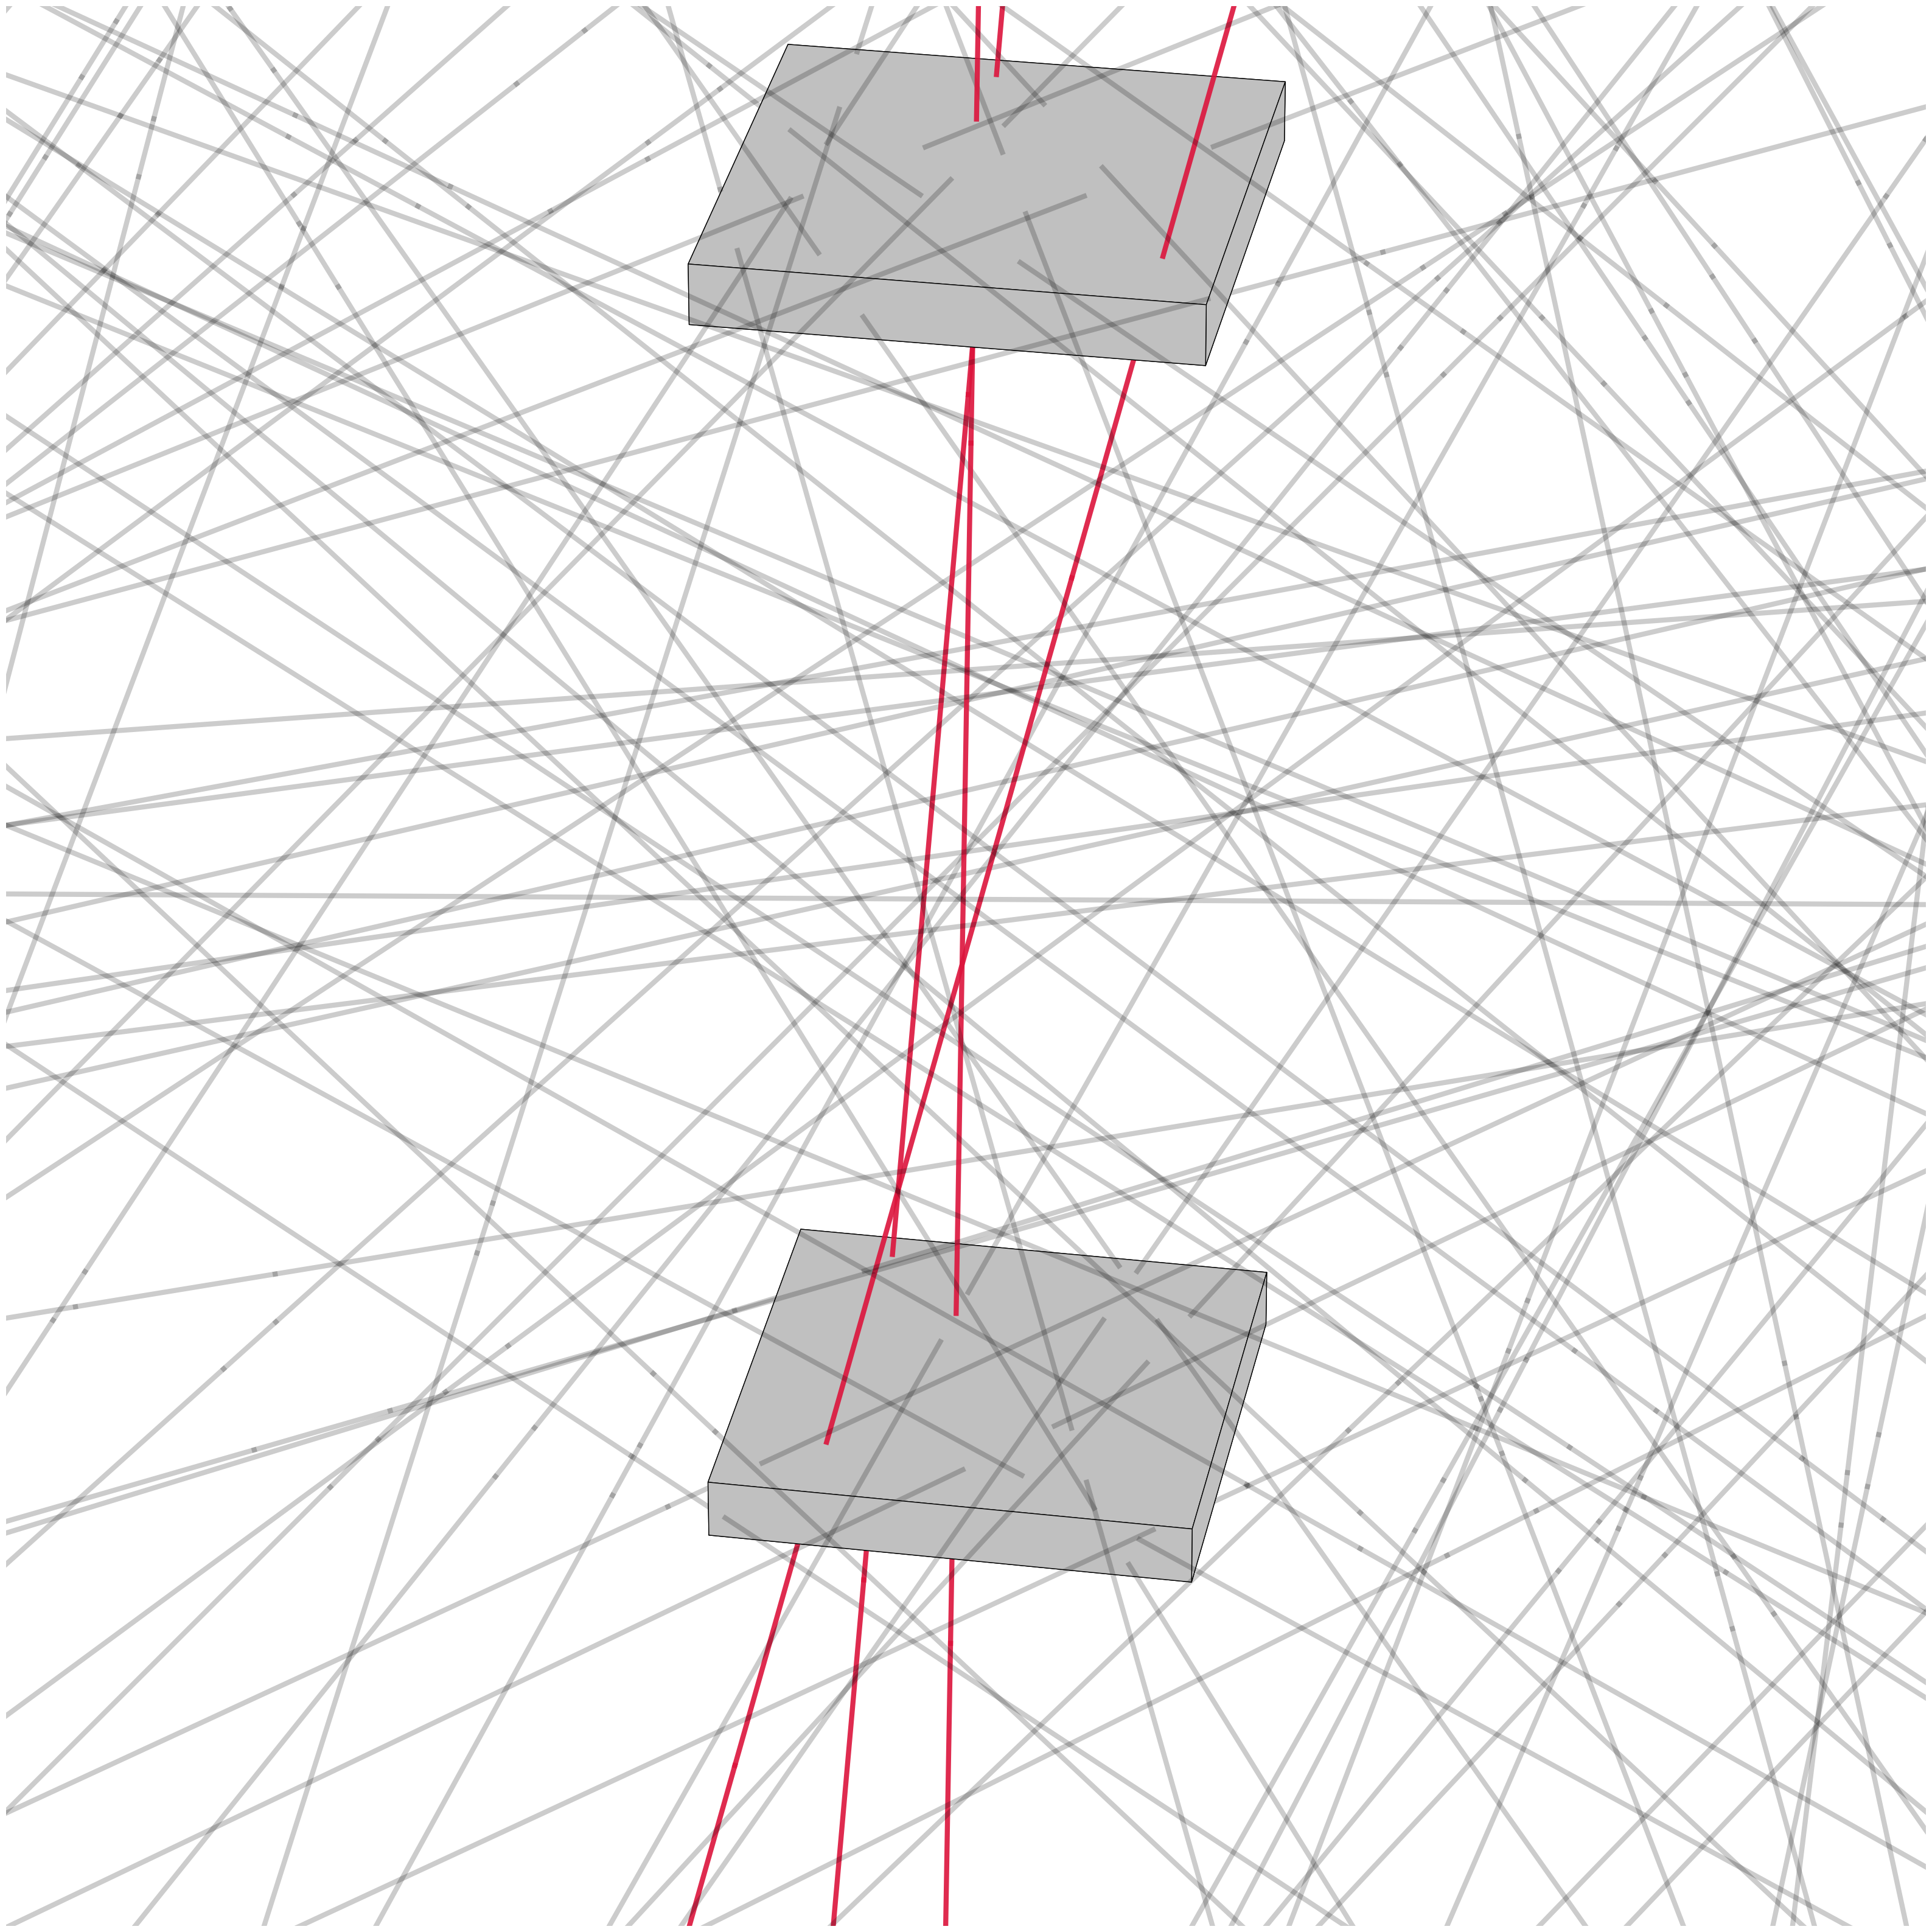

In [19]:
fig = plt.figure(figsize=(40, 32))
ax = fig.add_subplot(111, projection='3d', computed_zorder=False)

path_length = 100
v1 = draw_prism(ax, [0, 0, det_delta + det_height / 2], det_size, rot_ang=0, color='silver', alpha=1)
v9 = draw_prism(ax, [0, 0, det_height / 2], det_size, rot_ang=0, color='silver', alpha=1)

center_top_up = np.array([0, 0, det_delta + det_height])
center_top_down = np.array([0, 0, det_delta])
center_bottom_up = np.array([0, 0,det_height])
center_bottom_down = np.array([0,0,0])

normal = np.array([0, 0, 1])
u = np.array([1, 0, 0]) # x-axis direction on plane
v = np.array([0, 1, 0]) # y-axis direction on plane
half_len = det_size/2

colors = ['k', 'crimson']
alpha = [0.2,0.9]
detector_zorder = 10
zorders = [11,9,11,9,11]

mpl.rcParams['lines.linewidth'] = 6

camera_vec = get_camera_vector(elev_deg=30, azim_deg=10)
for path,det in zip(muon_paths, detected):
    origen,flecha = path
    det = int(det)

    points,t_points = intersection_points(origen,flecha,center_top_up,center_top_down,center_bottom_up,
                                    center_bottom_down,normal,u,v,half_len)
    
    start = origen - flecha*path_length/2
    end = origen + flecha*path_length/2
    if det:
        points[1] += flecha*5
        points[3] += flecha*6
        ax.scatter(*points[0],zorder=5,color='navy')
        ax.scatter(*points[2],zorder=5,color='navy')
    xy_min, xy_max = -2, 2

    segment_pairs = [
        (start, points[0]),      # Chunk 1
        (points[0], points[1]),  # Chunk 2
        (points[1], points[2]),  # Chunk 3
        (points[2], points[3]),  # Chunk 4
        (points[3], end),        # Chunk 5
    ]
    
    for i, (p0, p1) in enumerate(segment_pairs):
        # Compute midpoint
        mid = (p0 + p1) / 2
        z = zorders[i]  # Default depth-based zorder
    
        # Check if segment is inside detector XY space
        in_detector_xy = np.all((xy_min <= p0[:2]) & (p0[:2] <= xy_max)) and \
                         np.all((xy_min <= p1[:2]) & (p1[:2] <= xy_max))
    
        if in_detector_xy:
            if i in [0, 2]:  # Segments 1 and 3
                z = max(z, detector_zorder + 1)
            else:  # Segments 2, 4, 5
                z = min(z, detector_zorder - 1)
    
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]],
                color=colors[det], alpha=alpha[det], zorder=z)
# Final view adjustments
ax.view_init(elev=30, azim=10)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_zlim(2, 18)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('dibujo.png')
plt.show()